In [12]:
# ==================================================
# Data Science Job Market Analytics Project
# Author: Sampath Weerasekara
# Description:
# Load and explore the Data Science Salaries dataset
# ==================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["font.family"] = "DejaVu Sans"

# Load dataset
df = pd.read_csv("../data/ds_salaries.csv")

# Display first 5 rows
df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


# Data Understanding

The dataset contains salary and employment information for data science professionals worldwide.

The objective of this analysis is to:

- Understand salary trends
- Compare experience levels
- Analyse remote work adoption
- Identify high-paying job roles
- Explore company and employee locations

In [13]:
# ==================================================
# Dataset Overview
# ==================================================

# Display number of rows and columns
print(f"Dataset Shape: {df.shape}")

# Display column names
print("\nColumns:")
print(df.columns.tolist())

# Display dataset information
print("\nDataset Information:")
df.info()

Dataset Shape: (607, 12)

Columns:
['Unnamed: 0', 'work_year', 'experience_level', 'employment_type', 'job_title', 'salary', 'salary_currency', 'salary_in_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_s

# Data Quality Assessment

Before analysis, it is important to check:

- Missing values
- Duplicate records
- Data types
- Consistency of values

In [14]:
# ==================================================
# Check Missing Values
# ==================================================

print("Missing Values:")
print(df.isnull().sum())

# ==================================================
# Check Duplicate Records
# ==================================================

print("\nDuplicate Records:")
print(df.duplicated().sum())

Missing Values:
Unnamed: 0            0
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

Duplicate Records:
0


In [15]:
# ==================================================
# Remove Unnecessary Columns
# ==================================================

# 'Unnamed: 0' is an index column and is not needed

df = df.drop(columns=["Unnamed: 0"])

# Verify removal
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


# Feature Engineering

Several columns use abbreviations.

These will be converted into readable labels to improve analysis and visualisation.

In [16]:
# ==================================================
# Convert Experience Levels
# ==================================================

experience_map = {
    "EN": "Entry Level",
    "MI": "Mid Level",
    "SE": "Senior Level",
    "EX": "Executive"
}

df["experience_level"] = df["experience_level"].map(experience_map)

# Salary Analysis by Experience Level

Understanding how salaries change across experience levels provides insight into career progression within the data science industry.

In [17]:
# ==================================================
# Average Salary by Experience Level
# ==================================================

salary_by_exp = (
    df.groupby("experience_level")["salary_in_usd"]
    .mean()
    .sort_values()
)

salary_by_exp

experience_level
Entry Level      61643.318182
Mid Level        87996.056338
Senior Level    138617.292857
Executive       199392.038462
Name: salary_in_usd, dtype: float64

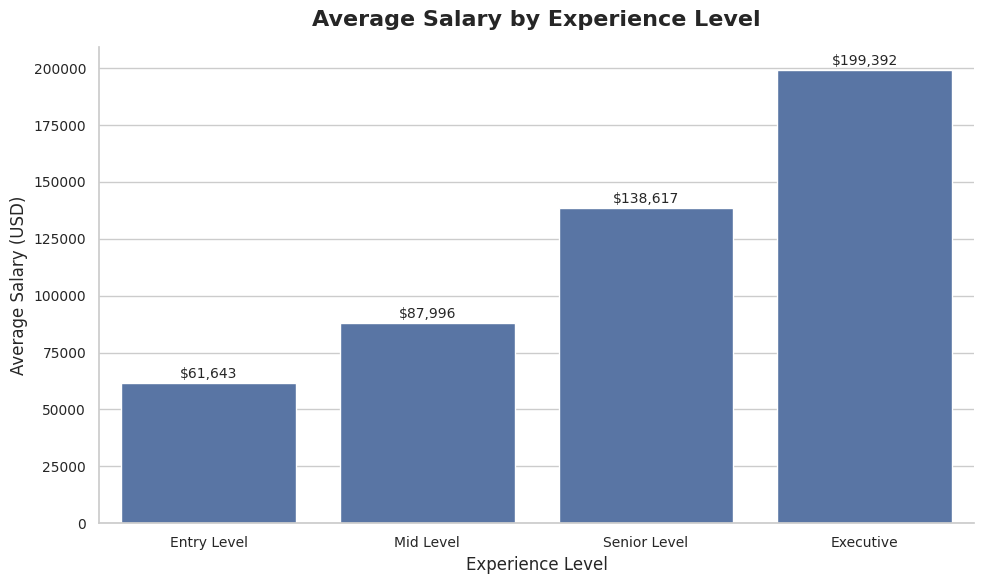

In [19]:
# ==================================================
# Visualise Average Salary by Experience Level
# ==================================================

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=salary_by_exp.index,
    y=salary_by_exp.values
)

# Add salary labels above bars
for i, value in enumerate(salary_by_exp.values):
    ax.text(
        i,
        value + 2000,
        f"${value:,.0f}",
        ha="center",
        fontsize=10
    )

# Professional formatting
plt.title(
    "Average Salary by Experience Level",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Experience Level", fontsize=12)
plt.ylabel("Average Salary (USD)", fontsize=12)

# Remove unnecessary borders
sns.despine()

plt.tight_layout()

# Save chart for GitHub README
plt.savefig(
    "../images/average_salary_by_experience.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Key Insight

Average salaries increase significantly with experience level.

Senior and Executive professionals command substantially higher salaries compared to Entry and Mid-Level positions, highlighting the value of experience within the data science industry.

In [20]:
# ==================================================
# Top 10 Highest Paying Data Science Roles
# ==================================================

top_roles = (
    df.groupby("job_title")["salary_in_usd"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_roles

job_title
Data Analytics Lead         405000.000000
Principal Data Engineer     328333.333333
Financial Data Analyst      275000.000000
Principal Data Scientist    215242.428571
Director of Data Science    195074.000000
Data Architect              177873.909091
Applied Data Scientist      175655.000000
Analytics Engineer          175000.000000
Data Specialist             165000.000000
Head of Data                160162.600000
Name: salary_in_usd, dtype: float64

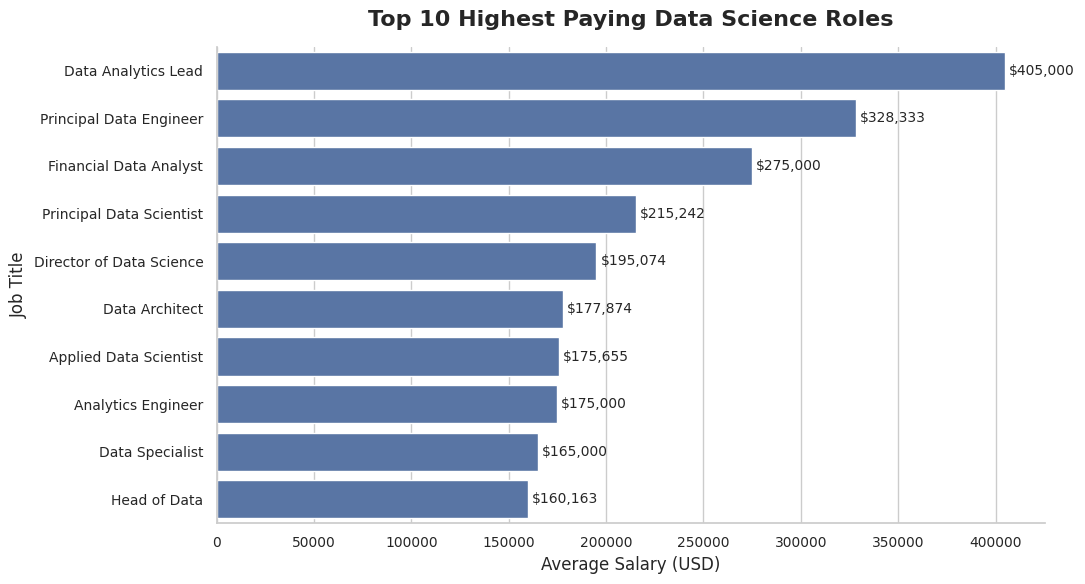

In [21]:
# ==================================================
# Visualise Top 10 Highest Paying Roles
# ==================================================

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    x=top_roles.values,
    y=top_roles.index
)

# Add salary labels
for i, value in enumerate(top_roles.values):
    ax.text(
        value + 2000,
        i,
        f"${value:,.0f}",
        va="center",
        fontsize=10
    )

plt.title(
    "Top 10 Highest Paying Data Science Roles",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Average Salary (USD)", fontsize=12)
plt.ylabel("Job Title", fontsize=12)

sns.despine()
plt.tight_layout()

plt.savefig(
    "../images/top_10_highest_paying_roles.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Key Insight

Specialist and leadership-focused data science roles tend to offer the highest average salaries, showing that advanced technical expertise and strategic responsibility are strongly rewarded in the data science job market.

# Remote Work Analysis

This section analyses how data science roles are distributed across onsite, hybrid, and fully remote work modes.

In [22]:
# ==================================================
# Remote Work Analysis
# ==================================================

remote_map = {
    0: "Onsite",
    50: "Hybrid",
    100: "Remote"
}

df["work_mode"] = df["remote_ratio"].map(remote_map)

work_mode_counts = df["work_mode"].value_counts()

work_mode_counts

work_mode
Remote    381
Onsite    127
Hybrid     99
Name: count, dtype: int64

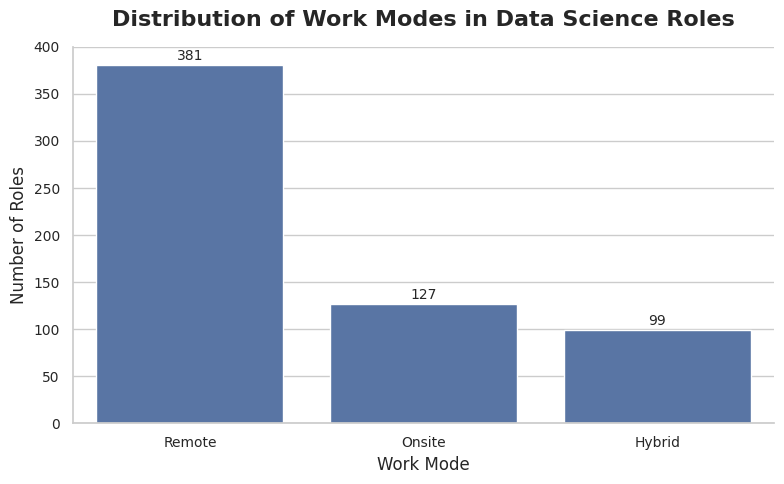

In [23]:
# ==================================================
# Visualise Work Mode Distribution
# ==================================================

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=work_mode_counts.index,
    y=work_mode_counts.values
)

# Add count labels
for i, value in enumerate(work_mode_counts.values):
    ax.text(
        i,
        value + 5,
        f"{value}",
        ha="center",
        fontsize=10
    )

plt.title(
    "Distribution of Work Modes in Data Science Roles",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Work Mode", fontsize=12)
plt.ylabel("Number of Roles", fontsize=12)

sns.despine()
plt.tight_layout()

plt.savefig(
    "../images/work_mode_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Key Insight

Remote roles represent a major part of the data science job market, showing that many organisations support flexible working arrangements for technical and analytical positions.

# Company Location Analysis

This section identifies the countries with the highest number of data science job opportunities based on company location.

In [25]:
# ==================================================
# Top Hiring Countries
# ==================================================

top_countries = (
    df["company_location"]
    .value_counts()
    .head(10)
)

top_countries

company_location
US    355
GB     47
CA     30
DE     28
IN     24
FR     15
ES     14
GR     11
JP      6
NL      4
Name: count, dtype: int64

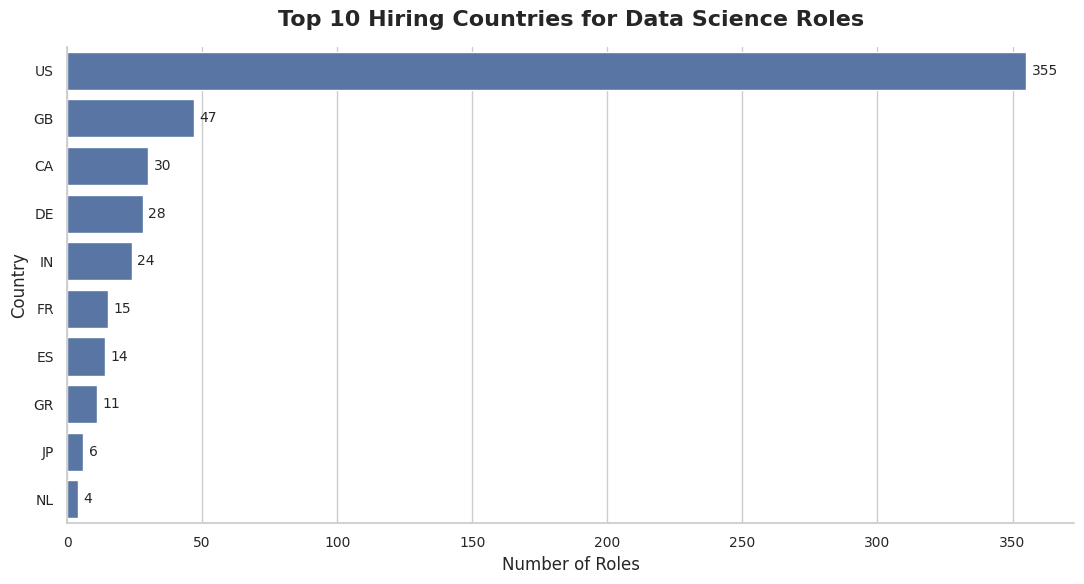

In [26]:
# ==================================================
# Visualise Top Hiring Countries
# ==================================================

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

# Add labels
for i, value in enumerate(top_countries.values):
    ax.text(
        value + 2,
        i,
        str(value),
        va="center",
        fontsize=10
    )

plt.title(
    "Top 10 Hiring Countries for Data Science Roles",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Number of Roles", fontsize=12)
plt.ylabel("Country", fontsize=12)

sns.despine()
plt.tight_layout()

plt.savefig(
    "../images/top_hiring_countries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Key Insight

A small number of countries account for a large proportion of data science opportunities. This concentration highlights the importance of major technology and business hubs in driving demand for analytical and AI-related talent.

# Salary Distribution by Experience Level

Average salaries provide a useful overview, but they can hide variation within each group.

A boxplot allows us to understand salary distribution, spread, and outliers across different experience levels.

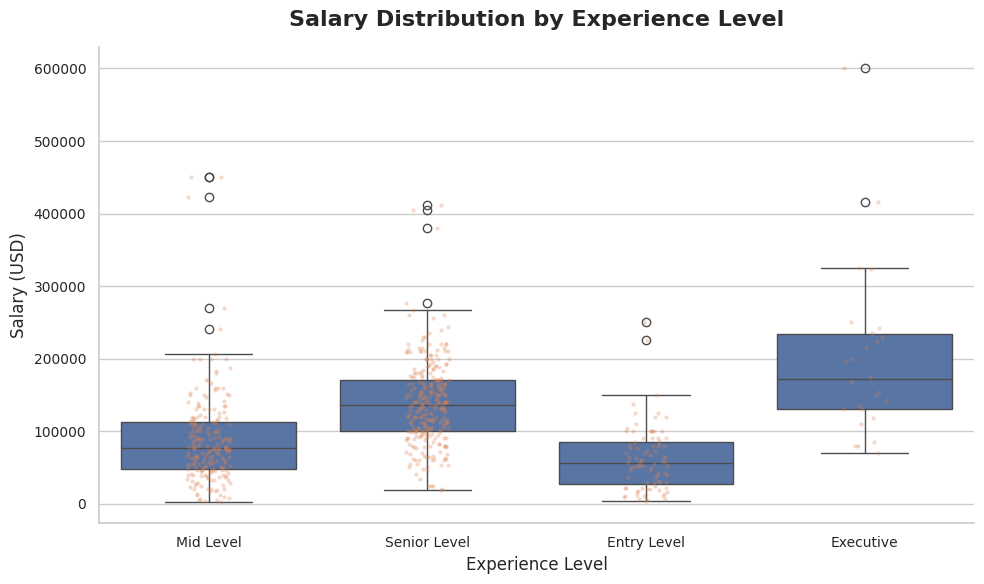

In [28]:
# ==================================================
# Salary Distribution by Experience Level
# ==================================================

plt.figure(figsize=(10, 6))

ax = sns.boxplot(
    data=df,
    x="experience_level",
    y="salary_in_usd"
)

sns.stripplot(
    data=df,
    x="experience_level",
    y="salary_in_usd",
    alpha=0.3,
    size=3
)

plt.title(
    "Salary Distribution by Experience Level",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Experience Level", fontsize=12)
plt.ylabel("Salary (USD)", fontsize=12)

sns.despine()

plt.tight_layout()

plt.savefig(
    "../images/salary_distribution_by_experience.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Key Insight

Salary variability increases with experience level. Senior and Executive professionals not only earn higher salaries on average, but also show a wider salary range, reflecting differences in industry, location, and organisational responsibility.

# Company Size and Salary Analysis

Company size can influence compensation due to differences in resources, business scale, and organisational structure.

This analysis compares average salaries across small, medium, and large companies.

In [29]:
# ==================================================
# Average Salary by Company Size
# ==================================================

salary_by_company_size = (
    df.groupby("company_size")["salary_in_usd"]
    .mean()
    .sort_values()
)

salary_by_company_size

company_size
S     77632.674699
M    116905.466258
L    119242.994949
Name: salary_in_usd, dtype: float64

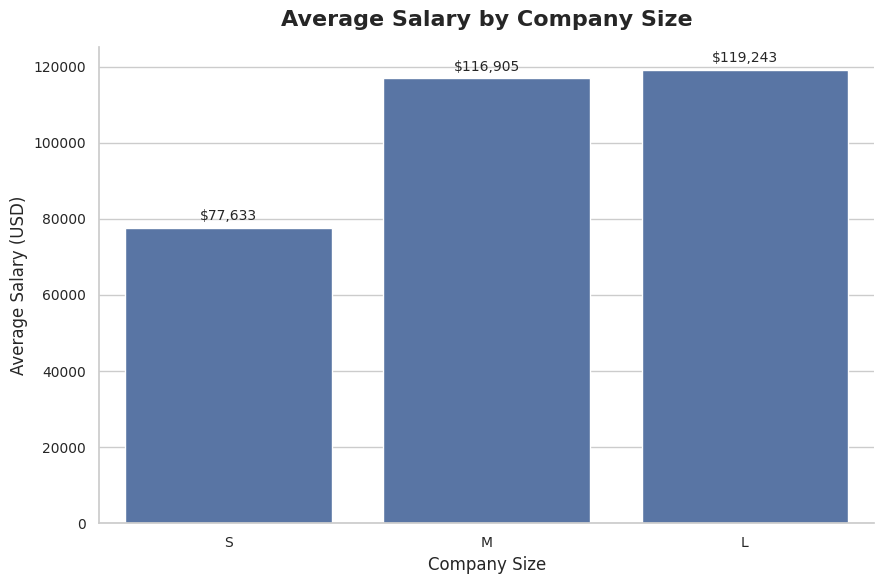

In [30]:
# ==================================================
# Visualise Salary by Company Size
# ==================================================

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    x=salary_by_company_size.index,
    y=salary_by_company_size.values
)

# Add salary labels
for i, value in enumerate(salary_by_company_size.values):
    ax.text(
        i,
        value + 2000,
        f"${value:,.0f}",
        ha="center",
        fontsize=10
    )

plt.title(
    "Average Salary by Company Size",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Company Size", fontsize=12)
plt.ylabel("Average Salary (USD)", fontsize=12)

sns.despine()

plt.tight_layout()

plt.savefig(
    "../images/salary_by_company_size.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Key Insight

Company size has a noticeable impact on salary levels. Larger organisations generally offer higher compensation packages, likely due to greater financial resources and demand for specialised talent.

# Most Common Job Titles

Understanding the most common job titles provides insight into the structure of the data science job market and highlights where demand is concentrated.

In [31]:
# ==================================================
# Top 10 Most Common Job Titles
# ==================================================

top_jobs = (
    df["job_title"]
    .value_counts()
    .head(10)
)

top_jobs

job_title
Data Scientist                143
Data Engineer                 132
Data Analyst                   97
Machine Learning Engineer      41
Research Scientist             16
Data Science Manager           12
Data Architect                 11
Big Data Engineer               8
Machine Learning Scientist      8
Principal Data Scientist        7
Name: count, dtype: int64

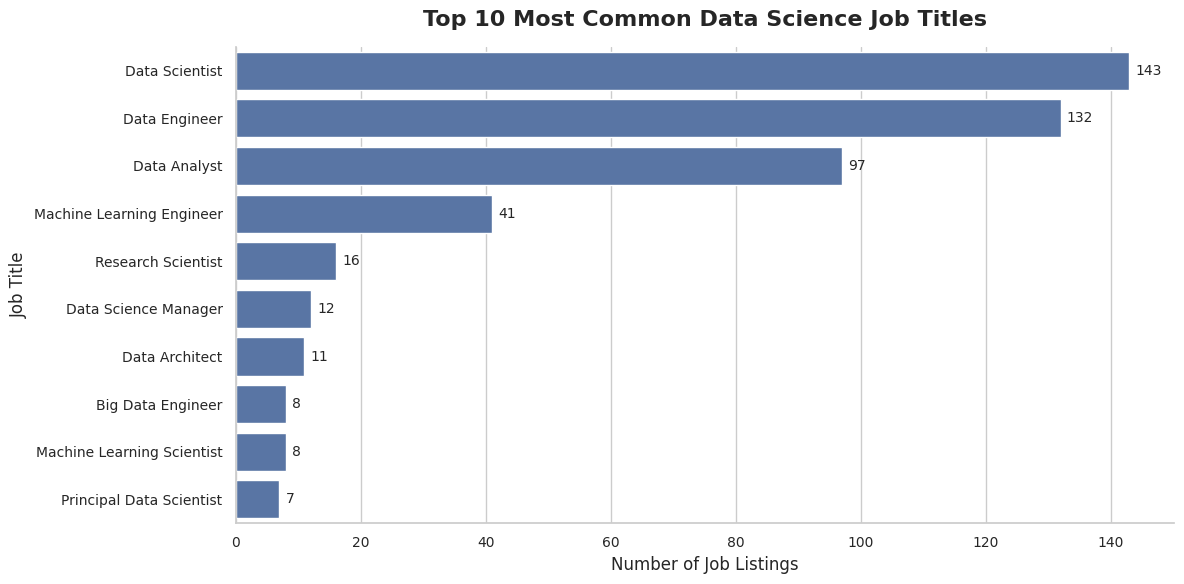

In [32]:
# ==================================================
# Visualise Top 10 Most Common Job Titles
# ==================================================

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=top_jobs.values,
    y=top_jobs.index
)

# Add count labels
for i, value in enumerate(top_jobs.values):
    ax.text(
        value + 1,
        i,
        str(value),
        va="center",
        fontsize=10
    )

plt.title(
    "Top 10 Most Common Data Science Job Titles",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Number of Job Listings", fontsize=12)
plt.ylabel("Job Title", fontsize=12)

sns.despine()

plt.tight_layout()

plt.savefig(
    "../images/top_job_titles.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Key Insight

Data Scientist, Data Engineer, and Data Analyst roles dominate the dataset, indicating strong demand for professionals who can extract insights, build data pipelines, and develop machine learning solutions.

# Salary Trends Over Time

This analysis explores how average salaries have evolved across different years within the dataset.

In [33]:
# ==================================================
# Average Salary by Year
# ==================================================

salary_by_year = (
    df.groupby("work_year")["salary_in_usd"]
    .mean()
)

salary_by_year

work_year
2020     95813.000000
2021     99853.792627
2022    124522.006289
Name: salary_in_usd, dtype: float64

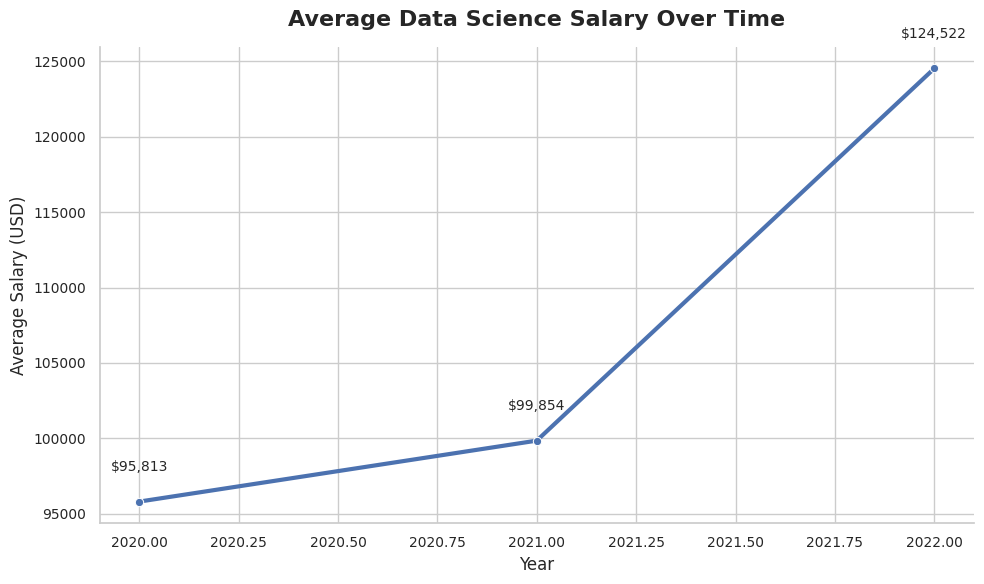

In [34]:
plt.figure(figsize=(10, 6))

ax = sns.lineplot(
    x=salary_by_year.index,
    y=salary_by_year.values,
    marker="o",
    linewidth=3
)

# Add labels
for x, y in zip(salary_by_year.index, salary_by_year.values):
    plt.text(
        x,
        y + 2000,
        f"${y:,.0f}",
        ha="center",
        fontsize=10
    )

plt.title(
    "Average Data Science Salary Over Time",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Salary (USD)", fontsize=12)

sns.despine()

plt.tight_layout()

plt.savefig(
    "../images/salary_trend_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Key Insight

Average salaries show an upward trend over time, reflecting the growing importance of data-driven decision making and increasing demand for analytics and machine learning expertise.

# Experience Level Distribution

Understanding the distribution of experience levels helps identify where the majority of hiring activity occurs.

In [35]:
# ==================================================
# Experience Level Distribution
# ==================================================

experience_counts = (
    df["experience_level"]
    .value_counts()
)

experience_counts

experience_level
Senior Level    280
Mid Level       213
Entry Level      88
Executive        26
Name: count, dtype: int64

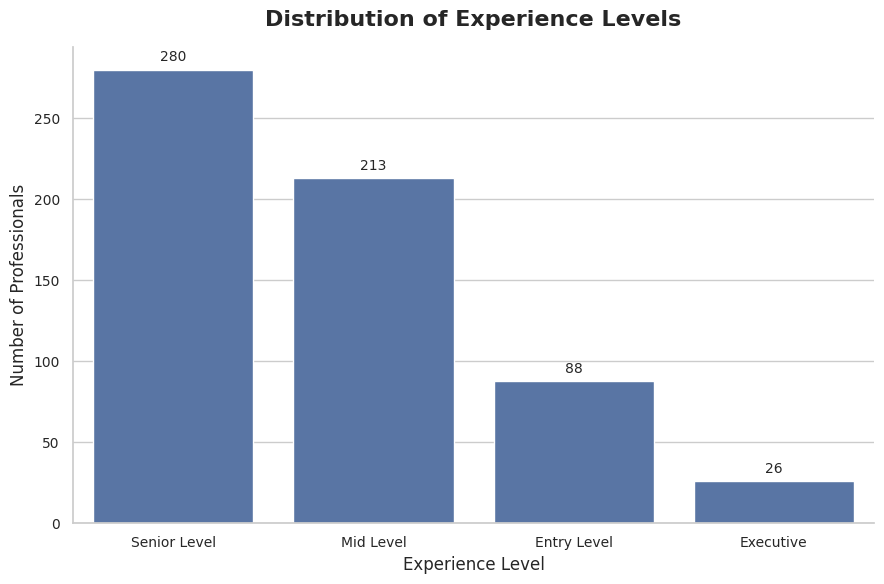

In [36]:
plt.figure(figsize=(9, 6))

ax = sns.barplot(
    x=experience_counts.index,
    y=experience_counts.values
)

for i, value in enumerate(experience_counts.values):
    ax.text(
        i,
        value + 5,
        str(value),
        ha="center",
        fontsize=10
    )

plt.title(
    "Distribution of Experience Levels",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Experience Level")
plt.ylabel("Number of Professionals")

sns.despine()
plt.tight_layout()

plt.savefig(
    "../images/experience_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Key Insight

Mid-Level and Senior-Level professionals represent the majority of the workforce, suggesting that organisations place significant value on practical experience and domain expertise.

# Employment Type Analysis

This analysis compares compensation across different employment arrangements.

In [37]:
salary_by_employment = (
    df.groupby("employment_type")["salary_in_usd"]
    .mean()
    .sort_values()
)

salary_by_employment

employment_type
PT     33070.500000
FL     48000.000000
FT    113468.073129
CT    184575.000000
Name: salary_in_usd, dtype: float64

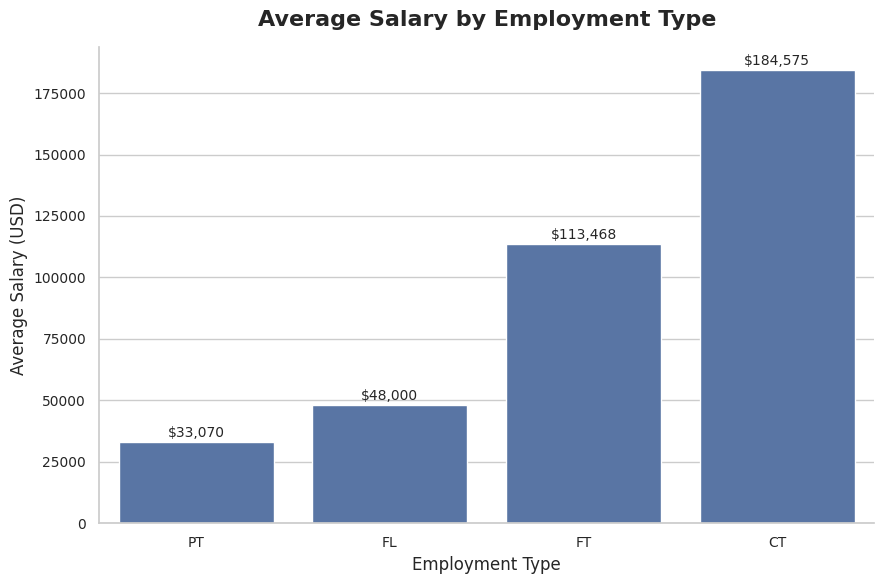

In [38]:
plt.figure(figsize=(9, 6))

ax = sns.barplot(
    x=salary_by_employment.index,
    y=salary_by_employment.values
)

for i, value in enumerate(salary_by_employment.values):
    ax.text(
        i,
        value + 2000,
        f"${value:,.0f}",
        ha="center",
        fontsize=10
    )

plt.title(
    "Average Salary by Employment Type",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Employment Type")
plt.ylabel("Average Salary (USD)")

sns.despine()
plt.tight_layout()

plt.savefig(
    "../images/salary_by_employment_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Key Insight

Compensation varies considerably across employment arrangements, with full-time and specialised contract positions often attracting higher salaries than alternative working arrangements.

# Executive Summary

Key findings from this analysis include:

1. Executive and Senior professionals earn the highest salaries.
2. Data Scientist and Data Engineer are among the most common roles.
3. Remote work plays a significant role in the industry.
4. Salary levels have increased over time.
5. Larger organisations generally offer higher compensation.

# Recommendations

Based on the analysis, the following observations may be useful for aspiring data professionals and organisations:

## For Job Seekers

- Develop skills relevant to Data Scientist and Data Engineer roles, as they represent a significant portion of market demand.
- Focus on gaining practical experience, as salary levels increase substantially with experience.
- Consider opportunities in countries and organisations with strong data-driven industries.

## For Organisations

- Competitive salary packages are important for attracting experienced talent.
- Flexible and remote working arrangements remain a significant feature of the data science job market.
- Investment in employee development can help address the demand for experienced professionals.

In [39]:
# Save cleaned dataset

df.to_csv("../data/clean_ds_salaries.csv", index=False)